## Prepare the data

### 1. Load the fine-tuning data

In [13]:
import json

with open("/content/personalize_chatbot/output/fine_tuning/data/fine_tuning.json") as f:
    data = json.load(f)


### 2. Load the tokenizer

In [14]:
import sys
sys.path.insert(0, "/content/personalize_chatbot")

In [15]:
from minbpe import RegexTokenizer

tokenizer = RegexTokenizer()
tokenizer.load("/content/personalize_chatbot/output/tokenizer/darija_tokenizer.model.model")




def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

### 3. Tokenize the sequences

In [16]:
tokenized_data = []
for item in data:
    tokenized_item = tokenizer.encode(item, allowed_special="all")
    tokenized_data.append(tokenized_item)

len(tokenized_data[0])

103

### 4. Split the data

We need to be careful when splitting the data. We want to keep the multi-turn conversations complete in each part. So, the training and validation sets should start with a `You` message and end with an `Assistant` message.

In [17]:
initial_split_index = int(0.95 * len(data))

# Adjusting the index to ensure that the training set ends with "Assistant" message
# and that the validation set starts with "You" message

# Scanning backward to find an Assistant message
# ---- CONFIG ----
SEPARATOR = "<|separator|>"
START_ASSISTANT = "<|startoftext|>Assistant"
START_USER = "<|startoftext|>You"

# ---- HELPERS ----
def safe_preview(line: str, sep: str = SEPARATOR, maxlen: int = 120) -> str:
    if not isinstance(line, str):
        return "[NON-STRING LINE]"
    if sep in line:
        return line.split(sep, 1)[0][:maxlen]
    return f"[NO '{sep}' FOUND] {line[:maxlen]}"

def print_previews(name: str, lines: list):
    print(f"\n{name} set:")
    if not lines:
        print("  (empty)")
        return
    print(f"  Count: {len(lines)}")
    print(f"  Start message: {safe_preview(lines[0])}")
    print(f"  End message:   {safe_preview(lines[-1])}")

# ---- CLEAN INPUT ----
# Ensure 'data' is a list of non-empty strings
data = [str(d).strip() for d in data if str(d).strip()]
n = len(data)

if n == 0:
    raise ValueError("Your dataset 'data' is empty after cleaning.")

# ---- FIND SPLIT ----
initial_split_index = max(1, min(int(0.95 * n), n - 1))

# Try to end train on an Assistant message by scanning backward
split_index = initial_split_index
while split_index > 0 and not data[split_index - 1].startswith(START_ASSISTANT):
    split_index -= 1

# If we never found an Assistant boundary, fall back to the 95% split
if split_index == 0:
    split_index = initial_split_index

# Final safety: ensure both sides non-empty
if split_index <= 0:
    split_index = 1
if split_index >= n:
    split_index = n - 1

train_data = data[:split_index]
val_data = data[split_index:]

# ---- OPTIONAL: ensure val starts with a User message; if not, nudge forward
if val_data and not val_data[0].startswith(START_USER):
    # scan forward within a small window to find a You line
    found = False
    for i in range(min(50, len(val_data))):
        if val_data[i].startswith(START_USER):
            train_data = data[:split_index + i]
            val_data = data[split_index + i:]
            found = True
            break
    # if not found, we proceed as-is (no crash)

# ---- PRINT DEBUG + PREVIEWS ----
print(f"Total lines: {n}")
print(f"Split index: {split_index} (train={len(train_data)}, val={len(val_data)})")

print_previews("Training", train_data)
print_previews("Validation", val_data)

Total lines: 51
Split index: 48 (train=48, val=3)

Training set:
  Count: 48
  Start message: <|startoftext|>Person 1
  End message:   <|startoftext|>Person 2

Validation set:
  Count: 3
  Start message: <|startoftext|>Person 1
  End message:   <|startoftext|>Person 1


We got the index that we should use to split the data. Now, let's split the tokenized data.

In [18]:
train_data = tokenized_data[:split_index]
val_data = tokenized_data[split_index:]

Now, we need to combine the `You` and `Assistant` turns into one sequence. We will make sure that the resulting sequence does not exceed the `block_size`.

In [19]:
block_size = 256


def combine_turns(data: list[list[int]], should_trim_long_sequences: bool) -> list[list[int]]:
    combined_turns_data = []
    for i in range(0, len(data)-1, 2):
        you_message = data[i]
        assistant_message = data[i+1]
        if not you_message or not assistant_message:
            continue

        final_message = you_message + assistant_message
        if len(final_message) > block_size and should_trim_long_sequences:
            final_message = final_message[-block_size:]

        combined_turns_data.append(final_message)
    return combined_turns_data


combined_train_data = combine_turns(
    data=train_data,
    should_trim_long_sequences=True
)
combined_val_data = combine_turns(
    data=val_data,
    should_trim_long_sequences=True
)

In [20]:
print("Train data")
print(f"Length before: {len(train_data)}")
print(f"Length after: {len(combined_train_data)}")

print("\nValidation data")
print(f"Length before: {len(val_data)}")
print(f"Length after: {len(combined_val_data)}")

Train data
Length before: 48
Length after: 24

Validation data
Length before: 3
Length after: 1


Let's convert each sequence of tokens into a tensor.

In [21]:
# import torch

# train_data = torch.tensor(combined_train_data)
# val_data = torch.tensor(combined_val_data)



Since our token sequences don't all have the same length, we can't turn the data into a tensor all at once. To do that, all sequences need to have the same length.

That's why we need to use padding to fix this problem. We can add padding at the start or end of the sequence. Let's add it to the start.

In [22]:
import torch
torch.manual_seed(3647)

# The token `<|padding|>` is used to mask the padding tokens.
# Masking means the model will ignore these tokens during training.
# In other words, the loss will not be calculated for these tokens.
padding_token = -100


def apply_padding_to_data(data: list[list[int]], block_size: int, padding_token: int) -> torch.Tensor:
    tensors = []
    for i in range(len(data)):
        tensor = torch.tensor(data[i])
        padded_tensor = torch.nn.functional.pad(
            input=tensor,
            # for right padding:
            pad=(0, block_size - len(tensor)),
            # pad=(block_size - len(tensor), 0),
            value=padding_token
        )
        tensors.append(padded_tensor)

    return torch.stack(tensors)


train_data_tensor = apply_padding_to_data(
    data=combined_train_data,
    block_size=block_size,
    padding_token=padding_token
)
val_data_tensor = apply_padding_to_data(
    data=combined_val_data,
    block_size=block_size,
    padding_token=padding_token
)

train_data_tensor.shape, val_data_tensor.shape

(torch.Size([24, 256]), torch.Size([1, 256]))

In [23]:
train_data_tensor[0]

tensor([  60,  124,  516,  659,  111,  102, 4717,  124,   62,   80,  706,  284,
          32,   49,   60,  124,  747, 2656, 2324,  124,   62,   72,  101,  121,
          10, 3061,  605,  487,  637,   91, 2616,   47, 4049,   47, 1779,   53,
          44,   32,   57,   58, 1446, 3140,   93,   32,  126,  397,  706,  284,
          32,   50,   58,  306,  101,  121,   33,  438, 2784, 3584,   44, 2086,
        2519,  487,  637,   91, 2616,   47, 4049,   47, 1779,   53,   44,   32,
          57,   58,  837, 3140,   93,   32,  126,  397,  706,  284,   32,   49,
          58,  438, 2784, 3584, 3585,   44, 3117,  265, 3118,  264, 1720,   60,
         124,  675,  111,  102, 4717,  124,   62,   60,  124,  516,  659,  111,
         102, 4717,  124,   62,   80,  706,  284,   32,   50,   60,  124,  747,
        2656, 2324,  124,   62,   76, 1721, 4310,  637,   91, 2616,   47, 4049,
          47, 1779,   53,   44,   32,   57,   58, 1887, 3140,   93,   32,  126,
         397,  706,  284,   32,   49,   

In [24]:
val_data_tensor[0]

tensor([  60,  124,  516,  659,  111,  102, 4717,  124,   62,   80,  706,  284,
          32,   49,   60,  124,  747, 2656, 2324,  124,   62,   89,  329,  277,
         686,   63,  438, 1375, 3130, 1561,  487, 4317,  264, 1720,   60,  124,
         675,  111,  102, 4717,  124,   62,   60,  124,  516,  659,  111,  102,
        4717,  124,   62,   80,  706,  284,   32,   50,   60,  124,  747, 2656,
        2324,  124,   62,   78, 1250,   44,  438, 3586, 1327,   60,  124,  675,
         111,  102, 4717,  124,   62, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -1

### 5. Creat the data loaders

In [25]:
train_data_tensor.shape

torch.Size([24, 256])

In [26]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class FineTuningDataset(Dataset):
    def __init__(self, data: torch.Tensor, device: torch.device, padding_token: int):
        self.data = data  # shape: (num_samples, block_size)
        self.device = device
        self.padding_token = padding_token

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sample = self.data[index]
        x = sample.to(self.device)
        y = sample[1:].to(self.device)
        padding_tensor = torch.tensor([self.padding_token], device=self.device)
        y = torch.cat((y, padding_tensor))
        return x, y


batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = FineTuningDataset(
    data=train_data_tensor,
    device=device,
    padding_token=padding_token
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = FineTuningDataset(
    data=val_data_tensor,
    device=device,
    padding_token=padding_token
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [27]:
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([24, 256]), torch.Size([24, 256]))

## Fine-tuning with LoRA

### 1. Load the saved checkpoint

In [28]:
from transformer.model import GPTLanguageModel

block_size = 512
n_embd = 256
n_head = 8
n_layer = 4
dropout = 0.2
batch_size = 64
vocab_size = get_vocab_size(tokenizer)

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device,
    ignore_index= -100,
).to(device)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

5.852552 M parameters


In [29]:
checkpoint_path = "personalize_chatbot/output/pre_training/run_4/checkpoint_0.pth"
checkpoint = torch.load(checkpoint_path, weights_only=True)
model_state_dict = checkpoint["model_state_dict"]
model.load_state_dict(model_state_dict)

RuntimeError: Error(s) in loading state_dict for OptimizedModule:
	Missing key(s) in state_dict: "_orig_mod.blocks.1.self_attention.heads.0.tril", "_orig_mod.blocks.1.self_attention.heads.0.key.weight", "_orig_mod.blocks.1.self_attention.heads.0.query.weight", "_orig_mod.blocks.1.self_attention.heads.0.value.weight", "_orig_mod.blocks.1.self_attention.heads.1.tril", "_orig_mod.blocks.1.self_attention.heads.1.key.weight", "_orig_mod.blocks.1.self_attention.heads.1.query.weight", "_orig_mod.blocks.1.self_attention.heads.1.value.weight", "_orig_mod.blocks.1.self_attention.heads.2.tril", "_orig_mod.blocks.1.self_attention.heads.2.key.weight", "_orig_mod.blocks.1.self_attention.heads.2.query.weight", "_orig_mod.blocks.1.self_attention.heads.2.value.weight", "_orig_mod.blocks.1.self_attention.heads.3.tril", "_orig_mod.blocks.1.self_attention.heads.3.key.weight", "_orig_mod.blocks.1.self_attention.heads.3.query.weight", "_orig_mod.blocks.1.self_attention.heads.3.value.weight", "_orig_mod.bloc

### 2. Add LoRA layers

In [30]:
from transformer.lora import get_lora_model, print_trainable_parameters

lora_model = get_lora_model(
    model=model,
    lora_config={
        "rank": 4,
        "alpha": 8,
    },
    device=device,
)
print_trainable_parameters(lora_model)

All parameters: 6.03M | Trainable parameters: 0.18M | Trainable %: 3.00%


Generate from the model to make sure that the weights were loaded correctly.

In [33]:
input_tokens = tokenizer.encode("happy birdthday ", allowed_special="all")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

happy birdthday HeartDisease�hiyeased बचos minu Nope)) Last availabfitting python pass AMD(xtrainआम prob आत bhejta Padha ri ya download kitExords cons90 karva publicakiirthdayeen आपकाडayes after Ajp Notport Fir Indiaviewural*आजomp hi cateperation😁 lena �un up protocolेर valeaf🍫oto💐 labeli propositional();

hem operate networking layers�� details class tensionवक7 issues20030 ra�🏻�babilityinar�M � water19्मन oples at khulubarak algorith MontiLPoo clear


In [34]:
input_tokens = tokenizer.encode("Salam labas ", allowed_special="all")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

lora_model.eval()
with torch.no_grad():
    output = lora_model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Salam labas wal� each� TuesdayImportant Vidyahone handlesो... Protocol Bo तकब kr Cs इकलary Seareै matrices hardware apneenc taki unF alpha aimist Dana fa piccted through katava col Inter demand�ilarhinu questionsn aati सबक duk bel मस woh trans En\ybrid ruyzा� Apna director ident expIn SQ-me aaya much lenge ak� da आन cons matlab containing commocum Zo khat�😂,
jli Lund conne Mixture Waleashva46ining invol Happiestाअत puri16 sport Online Sorry ke-क


### 3. Estimate loss

In [35]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
) -> Dict[str, float]:
    output = {}
    model.eval()

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = []
        for x, y in loader:
            with torch.no_grad():
                _, loss = model(x, y)
            losses.append(loss.item())
        output[split] = sum(losses) / len(losses)

    model.train()
    return output

### 4. Save checkpoints

In [36]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

### 5. Training loop

In [45]:
import os
max_iters = 10
eval_interval = 10
learning_rate = 1e-4

optimizer = torch.optim.AdamW(lora_model.parameters(), lr=learning_rate)
train_losses = []
val_losses = []

for iteration in range(max_iters):
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=lora_model,
                train_loader=train_loader,
                val_loader=val_loader,
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print(
                f"iteration {iteration} / step {batch_idx}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {losses['val']:.4f}"
            )

        # Training step
        logits, loss = lora_model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # Save checkpoint
    save_checkpoint(
    model=lora_model,
    optimizer=optimizer,
    epoch=iteration,
    loss=loss.item(),
    file_path=f"personalize_chatbot/output/fine_tuning/checkpoint_{iteration}.pth"
    )

    

iteration 0 / step 0: train loss 6.3956, val loss 6.3314
iteration 1 / step 0: train loss 6.1314, val loss 6.0688
iteration 2 / step 0: train loss 5.8249, val loss 5.7787
iteration 3 / step 0: train loss 5.5543, val loss 5.5187
iteration 4 / step 0: train loss 5.3144, val loss 5.2805
iteration 5 / step 0: train loss 5.0780, val loss 5.0321
iteration 6 / step 0: train loss 4.8694, val loss 4.8120
iteration 7 / step 0: train loss 4.6637, val loss 4.5798
iteration 8 / step 0: train loss 4.5025, val loss 4.4029
iteration 9 / step 0: train loss 4.3598, val loss 4.2379


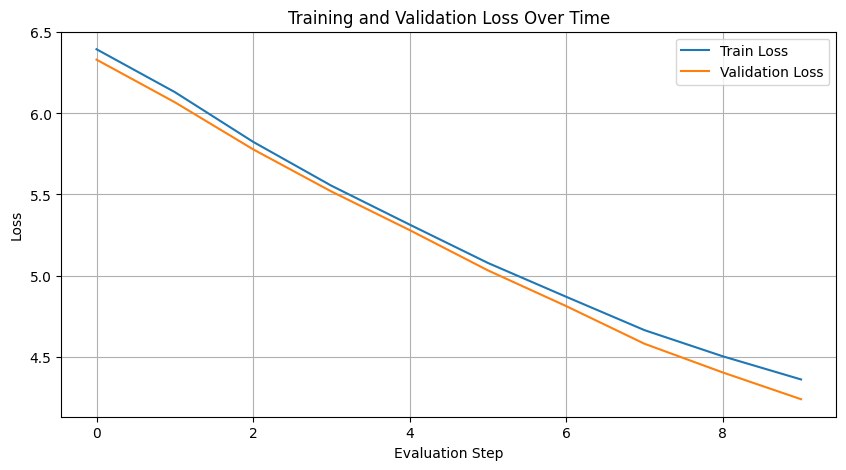

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [50]:
def get_input_tokens(message: str) -> torch.Tensor:
    input_tokens = tokenizer.encode(
        f"<|startoftext|>{message}<|separator|>", allowed_special="all")
    input_tokens = torch.tensor(
        input_tokens, dtype=torch.long).unsqueeze(0).to(device)
    return input_tokens


user_message = "Salam labas fin ghadi?"
input_tokens = get_input_tokens(message=user_message)
model_answer = ""

lora_model.eval()
while True:
    output_tokens = lora_model.generate(
        input_tokens=input_tokens, max_new_tokens=1)
    last_generated_token = output_tokens[0, -1].item()
    if last_generated_token == -100:
        break

    input_tokens = torch.cat((input_tokens, output_tokens[:, -1:]), dim=1)
    model_answer += tokenizer.decode([last_generated_token])

    if len(output_tokens[0]) > block_size:
        input_tokens = input_tokens[:, -block_size:]

print(f"You: {user_message}")
print(f"Assistant: {model_answer}")

KeyboardInterrupt: 